In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage


In [2]:
import pandas as pd
df = pd.read_csv("/content/Wholesale customers data.csv")
print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [4]:
X = df[[
    "Milk",
    "Grocery"
]]
X

,Milk,Grocery
0,9656,7561
1,9810,9568
2,8808,7684
3,1196,4221
4,5410,7198
...,...,...
435,12051,16027
436,1431,764
437,15488,30243
438,1981,2232


In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

In [8]:
clusters = kmeans.fit_predict(X)
df["Cluster"] = clusters

In [10]:
df["Cluster"] = clusters

for i in range(3):

    print("\n" + "="*50)
    print("CLUSTER", i + 1)
    print("="*50)

    cluster_data = df[
        df["Cluster"] == i
    ]

    print(
        cluster_data[
            [
                "Milk",
                "Grocery"
            ]
        ]
    )

    print(
        "\nTotal Records :",
        len(cluster_data)
    )


CLUSTER 1
     Milk  Grocery
0    9656     7561
2    8808     7684
3    1196     4221
4    5410     7198
5    8259     5126
..    ...      ...
433  3218     1493
434  3922     7994
436  1431      764
438  1981     2232
439  1698     2510

[320 rows x 2 columns]

Total Records : 320

CLUSTER 2
      Milk  Grocery
23   36423    22019
47   54259    55571
56   29892    26866
61   38369    59598
65   20959    45828
85   46197    92780
86   73498    32114
92   27472    32034
183  43950    20170
211  28326    39694
216  16599    36486
251  23133    33586
333   4980    67298

Total Records : 13

CLUSTER 3
      Milk  Grocery
1     9810     9568
9    11093    18881
10    5403    12974
12   12319    11757
13    6208    14982
..     ...      ...
426   9347    14316
427  16687     5429
430   4230    16483
435  12051    16027
437  15488    30243

[107 rows x 2 columns]

Total Records : 107


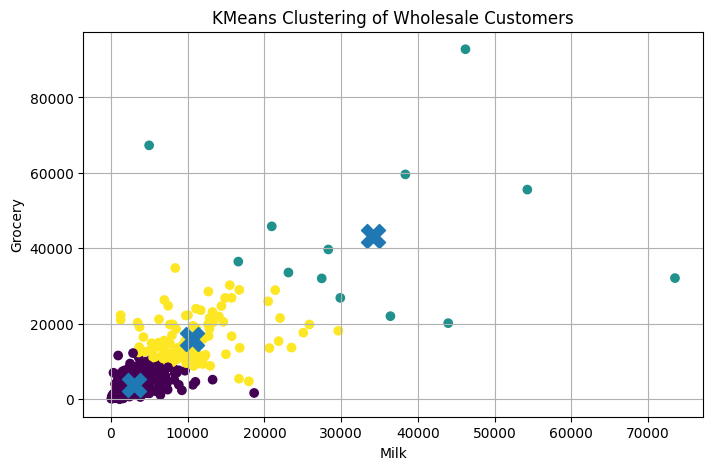

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    X["Milk"],
    X["Grocery"],
    c=clusters
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker="X"
)

plt.xlabel("Milk")
plt.ylabel("Grocery")

plt.title("KMeans Clustering of Wholesale Customers")

plt.grid(True)

plt.show()

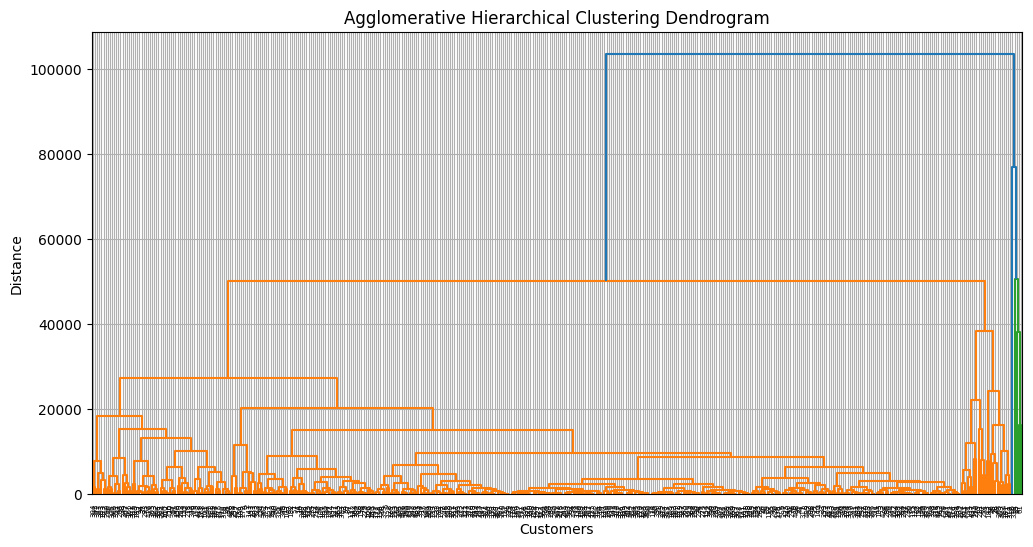

In [14]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(
    X,
    method="complete"
)

plt.figure(figsize=(12,6))

dendrogram(Z)

plt.title("Agglomerative Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.grid(True)

plt.show()

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [16]:
df = pd.read_csv("/content/Wholesale customers data.csv")
print(df.head())

   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [17]:
print("\nMissing Values")
print(df.isnull().sum())

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)


Missing Values
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


In [19]:
X = df[[
    "Milk",
    "Grocery"
]]

In [20]:
hc = AgglomerativeClustering(
    n_clusters=3
)

clusters = hc.fit_predict(X)

In [22]:
df["Cluster"] = clusters

for i in range(3):

    print("\n" + "="*50)
    print("CLUSTER", i)
    print("="*50)

    print(
        df[df["Cluster"] == i]
        [["Milk",
          "Grocery"]]
    )


CLUSTER 0
     Milk  Grocery
0    9656     7561
1    9810     9568
2    8808     7684
3    1196     4221
4    5410     7198
..    ...      ...
433  3218     1493
434  3922     7994
436  1431      764
438  1981     2232
439  1698     2510

[377 rows x 2 columns]

CLUSTER 1
      Milk  Grocery
9    11093    18881
23   36423    22019
28   20484    25957
38   15729    16709
43   11095    23998
45   22044    21531
46   14069    21955
49   21412    28921
56   29892    26866
63   11601    15775
65   20959    45828
71    1266    21042
77   12697    28540
92   27472    32034
101  10810    16267
107  10646    14886
109  16729    28986
111  11114    17569
145   8384    34792
155  10690    19460
163  15726    26870
165  12653    19858
171  25862    19816
173   7677    19805
181  29627    18148
183  43950    20170
193   3485    20292
200  13240    23127
201  14399    24708
205  11711    23596
209  12729    16767
211  28326    39694
215  10765    15538
216  16599    36486
251  23133    33586
264   

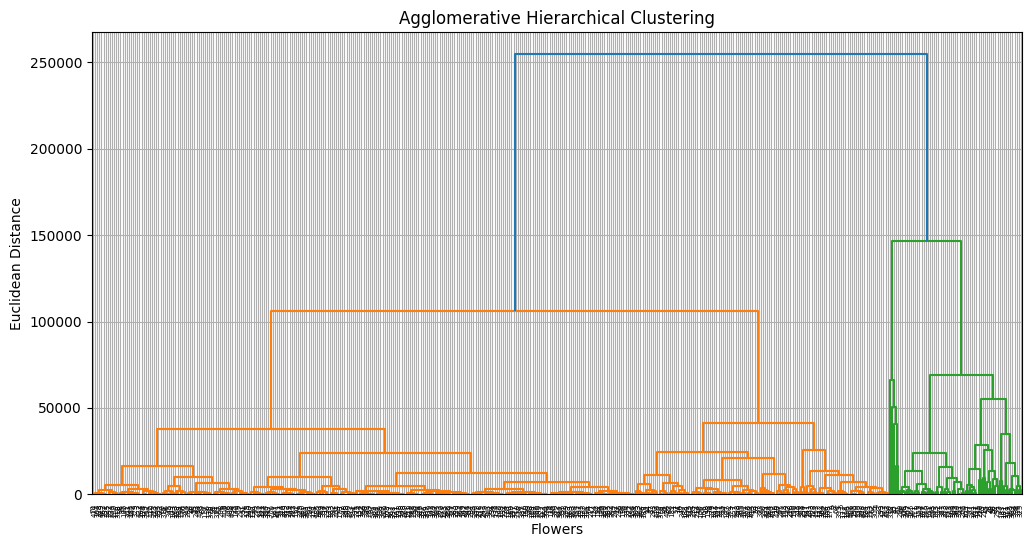

In [23]:
plt.figure(figsize=(12,6))

dendrogram(
    linkage(
        X,
        method="ward"
    )
)

plt.title("Agglomerative Hierarchical Clustering")
plt.xlabel("Flowers")
plt.ylabel("Euclidean Distance")

plt.grid(True)

plt.show()

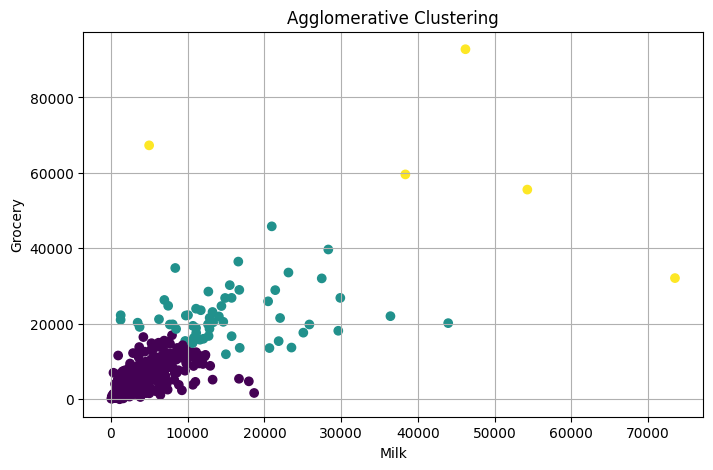

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(
    X["Milk"],
    X["Grocery"],
    c=clusters
)

plt.xlabel("Milk")
plt.ylabel("Grocery")

plt.title("Agglomerative Clustering")

plt.grid(True)

plt.show()